In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [4]:
set_seed

<function __main__.set_seed(seed=42)>

In [5]:
epochs = 20
loss_history = []

In [6]:
import torch
import torch.nn.functional as F
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.7.1+cu118
11.8


In [8]:
import torch_geometric
from torch_geometric.data import Data

print("PyG OK")

p:\Anaconda\envs\torch_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyG OK


In [9]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset, get_graph_dataloader, build_node_vocab, build_rel_vocab

In [10]:
import pandas as pd

In [11]:
df_train = pd.read_csv("../data/df_train.csv")
df_val = pd.read_csv("../data/df_val.csv")

all_labels = df_train["labels"].unique()

label2idx = {l: i for i, l in enumerate(all_labels)}
idx2label = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"] = df_val["labels"].map(label2idx)

node_vocab = build_node_vocab(df_train)
rel_vocab = build_rel_vocab(df_train)

In [12]:
train_dataset = GQAGraphDataset(
    df=df_train,
    label_col="labels",
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    label2idx= label2idx,
    idx2label = idx2label,
    use_bbox=True
)

val_dataset = GQAGraphDataset(
    df=df_val,
    label_col="labels",
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    label2idx= label2idx,
    idx2label = idx2label,
    use_bbox=True
)

NUM_CLASSES = len(label2idx)

train_loader = get_graph_dataloader(
    train_dataset,
    n_classes=NUM_CLASSES,
    n_samples=4,
)

In [13]:
from src.models.gnn import GCNEmbeddingNet

In [14]:
model = GCNEmbeddingNet(
    num_node_types=len(node_vocab) + 1,
    emb_dim=128,
    hidden_dim=256,
    num_layers=4,
    dropout=0.2,
    use_bbox=True,
    node_emb_dim=64,
)

In [15]:
from src.training.contrastiveloss import supervised_contrastive_loss_GNN
from src.training.train_model import train_graph_model_gcn

In [17]:
ckpt_dir = os.path.join(os.path.abspath(".."), "experiments", "checkpoints")
resume_from = None #os.path.join(ckpt_dir, "gnn10.pth")
resume_epoch = None  # solo se il .pth vecchio ha solo i pesi: es. 11 per continuare da epoca 11

model, history = train_graph_model_gcn(
    node_vocab=node_vocab,
    rel_vocab=rel_vocab,
    model=model,
    loader=train_loader,
    loss_fn=lambda emb, labels: supervised_contrastive_loss_GNN(emb, labels, temperature=0.07),
    device=device,
    epochs=epochs,
    lr=3e-4,
    weight_decay=1e-4,
    checkpoint_path=resume_from,
    resume_epoch=resume_epoch,
    save_path=os.path.join(ckpt_dir, f"gcn{epochs}.pth"),
)

p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 1/20 - loss: 3.5105 - lr: 2.98e-04
Epoch 2/20 - loss: 3.0520 - lr: 2.93e-04
Epoch 3/20 - loss: 2.8641 - lr: 2.84e-04
Epoch 4/20 - loss: 2.7335 - lr: 2.73e-04
Epoch 5/20 - loss: 2.6154 - lr: 2.58e-04
Epoch 6/20 - loss: 2.5418 - lr: 2.41e-04
Epoch 7/20 - loss: 2.4693 - lr: 2.22e-04
Epoch 8/20 - loss: 2.4041 - lr: 2.02e-04
Epoch 9/20 - loss: 2.3432 - lr: 1.80e-04
Epoch 10/20 - loss: 2.2828 - lr: 1.58e-04
Epoch 11/20 - loss: 2.2597 - lr: 1.35e-04
Epoch 12/20 - loss: 2.2154 - lr: 1.13e-04
Epoch 13/20 - loss: 2.1906 - lr: 9.28e-05
Epoch 14/20 - loss: 2.1525 - lr: 7.37e-05
Epoch 15/20 - loss: 2.1416 - lr: 5.67e-05
Epoch 16/20 - loss: 2.1150 - lr: 4.22e-05
Epoch 17/20 - loss: 2.0907 - lr: 3.05e-05
Epoch 18/20 - loss: 2.0747 - lr: 2.20e-05
Epoch 19/20 - loss: 2.0694 - lr: 1.68e-05
Epoch 20/20 - loss: 2.0570 - lr: 1.50e-05
Checkpoint saved to: p:\Uni\mujoco\dl26-projects\experiments\checkpoints\gcn20.pth


In [ ]:
print(history)

[3.453353136257638, 3.036680404087552, 2.827598073536024, 2.6881659566018348, 2.6022853176492706, 2.510954684747425, 2.4381133172280176, 2.392964096437963, 2.347395082067076, 2.279975573320936, 2.237843994190568, 2.1831830109741324, 2.158883314180255, 2.139537711987769, 2.099113220585849, 2.072841767063759, 2.0543666563723746, 2.0509551264104107, 2.0220820835403672, 2.034116794343601]


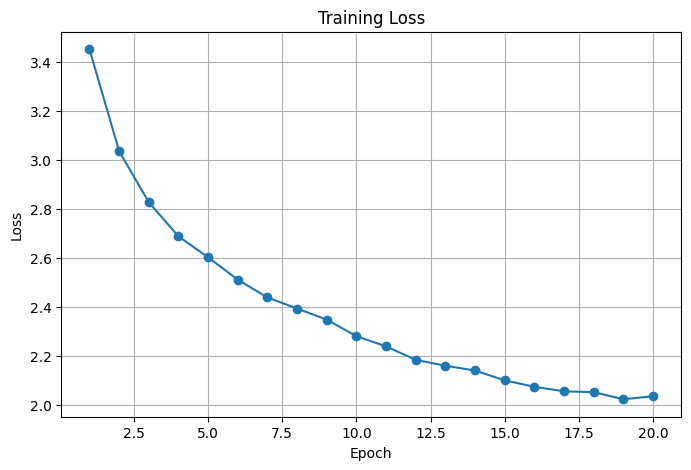

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [ ]:
import os
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
gcn_model = GCNEmbeddingNet(
    num_node_types=len(node_vocab) + 1,
    emb_dim=128,
    hidden_dim=256,
    num_layers=4,
    dropout=0.2,
    use_bbox=True,
    node_emb_dim=64,
).to(device)

parent_dir = os.path.abspath("..")
ckpt_path = os.path.join(
    parent_dir,
    "experiments",
    "checkpoints",
    f"gcn{epochs}.pth",
)

from src.training.train_model import load_model_weights

load_model_weights(ckpt_path, gcn_model, device)
gcn_model.eval()

GCNEmbeddingNet(
  (node_emb): Embedding(1638, 64, padding_idx=0)
  (node_encoder): Sequential(
    (0): Linear(in_features=68, out_features=256, bias=True)
    (1): ReLU()
    (2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (convs): ModuleList(
    (0-3): 4 x GCNConv(256, 256)
  )
  (norms): ModuleList(
    (0-3): 4 x LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (projector): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [ ]:
from src.evaluation.retrieval import (
    gcn_compute_graph_embeddings,
    evaluate_retrieval,
    print_metrics,
    plot_graph_retrieval,
    plot_tsne,
)

In [ ]:
embeddings, labels = gcn_compute_graph_embeddings(
    model=gcn_model,
    dataset=val_dataset,
    device=device,
    batch_size=64,
    num_workers=0,
    normalize=True,
)

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)


results, indices, scores = evaluate_retrieval(
    embeddings,
    labels,
    ks=(1, 5, 10),
)


print_metrics(results)

Embeddings shape: torch.Size([3208, 128])
Labels shape: torch.Size([3208])

========== Retrieval Metrics ==========

acc@1               : 0.5966
precision_macro     : 0.5673
recall_macro        : 0.5661
recall@1            : 0.5966
recall@5            : 0.8204
recall@10           : 0.8791
precision@1         : 0.5966
precision@5         : 0.6032
precision@10        : 0.6046
mrr                 : 0.6949
map                 : 0.6631



[1250 2366  158  503  593]


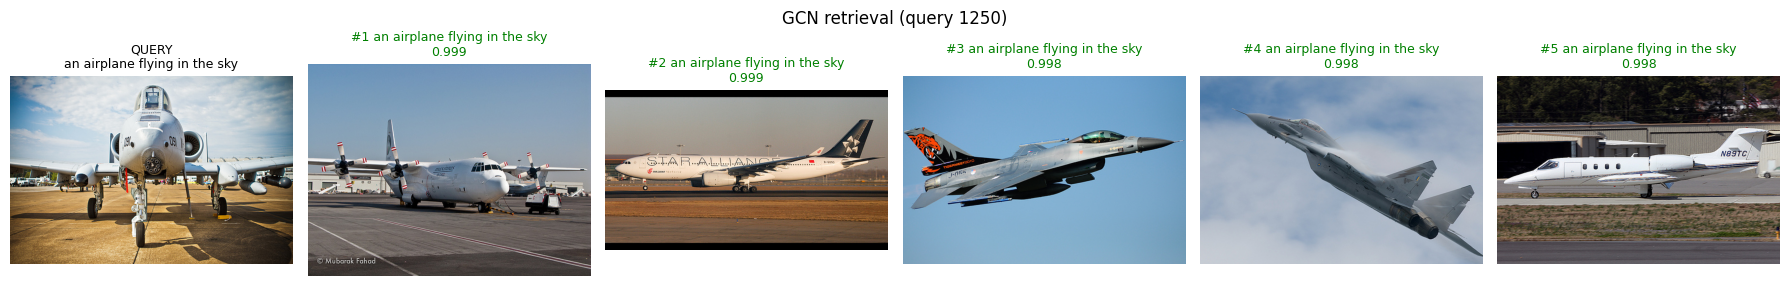


Query 1250: an airplane flying in the sky
#1 idx=133 score=0.999 an airplane flying in the sky [OK]
#2 idx=1090 score=0.999 an airplane flying in the sky [OK]
#3 idx=2926 score=0.998 an airplane flying in the sky [OK]
#4 idx=2743 score=0.998 an airplane flying in the sky [OK]
#5 idx=2784 score=0.998 an airplane flying in the sky [OK]


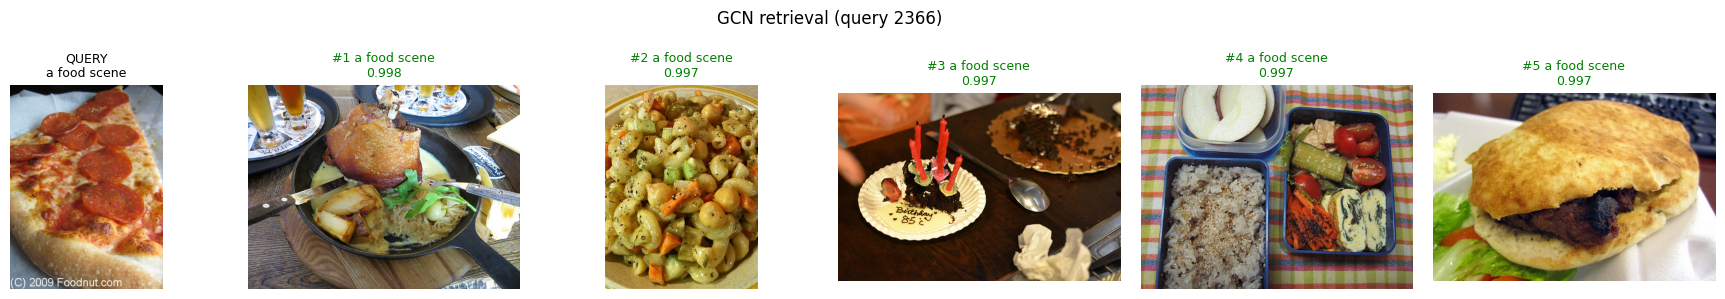


Query 2366: a food scene
#1 idx=2898 score=0.998 a food scene [OK]
#2 idx=2558 score=0.997 a food scene [OK]
#3 idx=1389 score=0.997 a food scene [OK]
#4 idx=328 score=0.997 a food scene [OK]
#5 idx=2598 score=0.997 a food scene [OK]


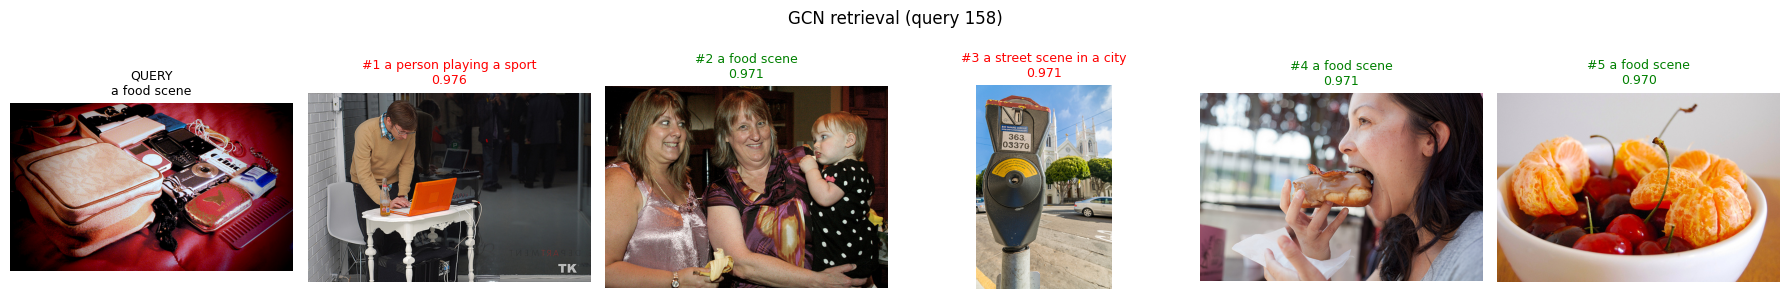


Query 158: a food scene
#1 idx=33 score=0.976 a person playing a sport [MISS]
#2 idx=1474 score=0.971 a food scene [OK]
#3 idx=2128 score=0.971 a street scene in a city [MISS]
#4 idx=3117 score=0.971 a food scene [OK]
#5 idx=513 score=0.970 a food scene [OK]


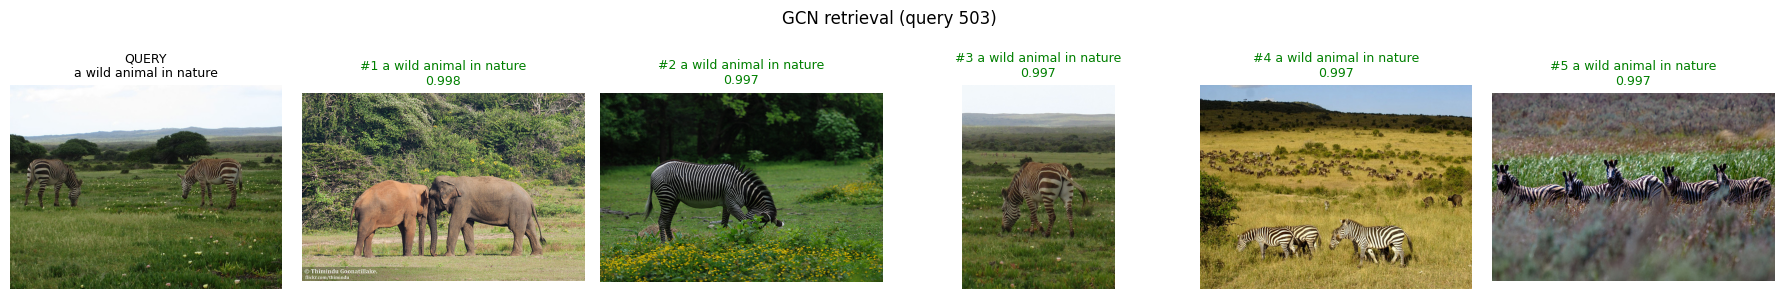


Query 503: a wild animal in nature
#1 idx=2372 score=0.998 a wild animal in nature [OK]
#2 idx=352 score=0.997 a wild animal in nature [OK]
#3 idx=1846 score=0.997 a wild animal in nature [OK]
#4 idx=1047 score=0.997 a wild animal in nature [OK]
#5 idx=1752 score=0.997 a wild animal in nature [OK]


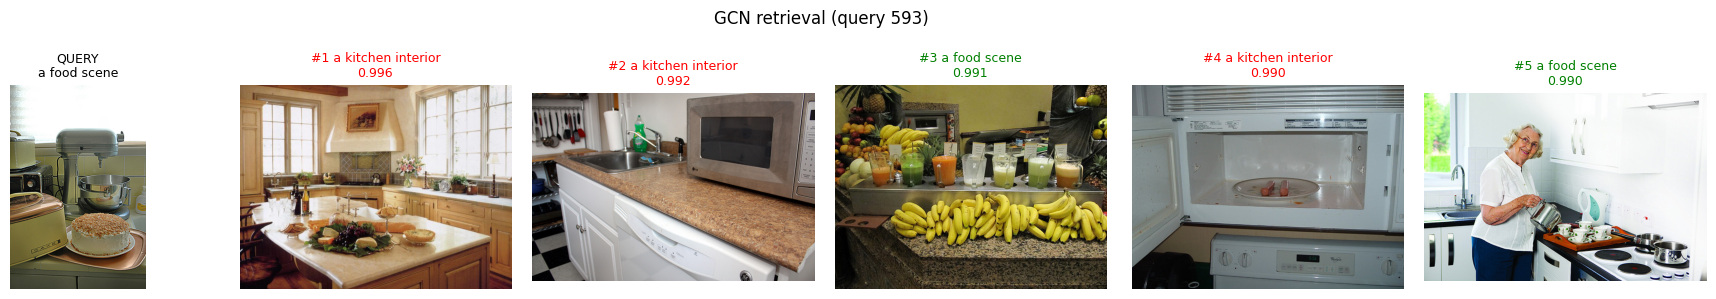


Query 593: a food scene
#1 idx=2725 score=0.996 a kitchen interior [MISS]
#2 idx=2814 score=0.992 a kitchen interior [MISS]
#3 idx=431 score=0.991 a food scene [OK]
#4 idx=646 score=0.990 a kitchen interior [MISS]
#5 idx=1708 score=0.990 a food scene [OK]


In [ ]:
IMAGE_DIR = os.path.join(os.path.abspath(".."), "data", "images")

np.random.seed(40)
query_indices = np.random.choice(len(labels), size=5, replace=False)

print(query_indices)
for query_idx in query_indices:


    plot_graph_retrieval(
        df=val_dataset,
        image_dir=IMAGE_DIR,
        labels=labels,
        indices=indices,
        scores=scores,
        query_idx=query_idx,
        idx2label=val_dataset.idx2label,
        topk=5,
        title=f"GCN retrieval (query {query_idx})",
    )

    q_label = labels[query_idx].item()
    print(f"\nQuery {query_idx}: {val_dataset.idx2label.get(q_label, q_label)}")

    for rank, (idx, score) in enumerate(
        zip(indices[query_idx][1:6], scores[query_idx][1:6]),
        start=1
    ):
        lbl = int(labels[idx])
        mark = "OK" if lbl == q_label else "MISS"

        print(
            f"#{rank} idx={idx} score={score:.3f} "
            f"{val_dataset.idx2label.get(lbl, lbl)} [{mark}]"
        )

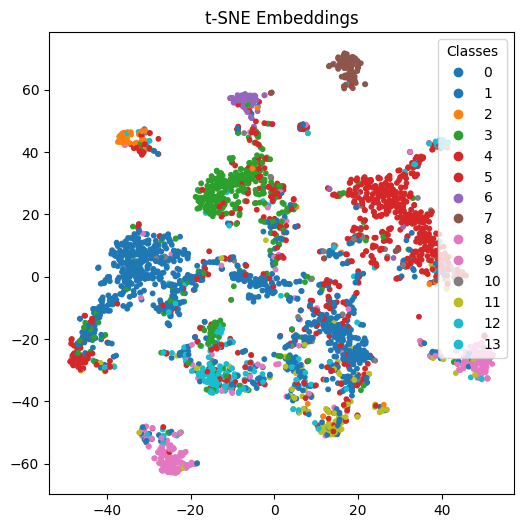

In [ ]:
plot_tsne(
    embeddings=embeddings,
    labels=labels
          )